In [1]:
import os
os.chdir('../..')

In [2]:
import selfies as sf
from scipy.spatial.distance import cosine, euclidean
from src.datasets import QM9Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import polars as pl
from rdkit import DataStructs, Chem
from rdkit.Chem import AllChem
from src.clusters import ClusterAnalysis

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
qm9 = QM9Dataset()
qm9.load()

2026-02-11 11:31:41.994 | INFO     | src.datasets:load:67 - Loading QM9 from data/QM9/dataset_cleaned.csv...


mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821
"""qm9_2011""","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,"""Aliphatic Ring""",98.101,0.4895,26.3,7,1,0,0,0.4,0,2,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565
"""qm9_2012""","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,"""Aliphatic Ring""",100.141,1.5652,33.03,7,1,0,0,1.0,0,1,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558


# Morgan Fingerprints

In [4]:
qm9.add_morgan_fingerprints(radius=3, fp_size=2048)

2026-02-11 11:31:42.013 | INFO     | src.features:compute_morgan_fingerprints:25 - Computing Morgan Fingerprints (Radius=3, Size=2048)...


In [5]:
qm9.df

mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8]
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]"
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]"
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]"
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]"
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0, 0, … 0]"
"""qm9_2011""","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,"""Aliphatic Ring""",98.101,0.4895,26.3,7,1,0,0,0.4,0,2,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565,"[0, 0, … 0]"
"""qm9_2012""","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,"""Aliphatic Ring""",100.141,1.5652,33.03,7,1,0,0,1.0,0,1,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558,"[0, 0, … 0]"


In [6]:
df_morgan = qm9.df['morgan_fingerprint']
df_morgan_list = list(df_morgan)

validating that it has done it correct. 

In [7]:
for _, ls in enumerate(df_morgan_list[0:4]):
    for i, val in enumerate(ls):
        if val == 1:
            print(i)

1264
930
790
915
1119


# Validate One-Hot and Transformer embeddings

In [8]:
qm9.add_selfies_transformer()
qm9.add_selfies_onehot()

2026-02-11 11:31:44.586 | INFO     | src.features:compute_selfies_transformer:45 - Loading Transformer model: seyonec/ChemBERTa-zinc-base-v1...
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2010.38it/s, Materializing param=pooler.dense.weight]                             
RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-02-11 11:31:56.272 | INFO     | src.features:compute_selfies_onehot:76 - Computing One-Hot Encodings...
2026-02-11 11:31:56.

In [9]:
qm9.df

mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_transformer,selfies_onehot
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[f64],list[list[i64]]
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[1.116855, 0.998924, … 0.737373]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]"
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[0.316447, 0.69667, … 1.264199]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]"
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[0.08437, 0.681181, … 0.699162]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]"
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[0.895405, 0.401674, … 0.650952]","[[0, 0, … 0], [1, 0, … 0], … [0, 0, … 1]]"
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[0.981024, 0.386095, … 1.052694]","[[0, 0, … 0], [0, 1, … 0], … [0, 0, … 1]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0, 0, … 0]","[0.299405, -0.013913, … 1.102453]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
"""qm9_2011""","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,"""Aliphatic Ring""",98.101,0.4895,26.3,7,1,0,0,0.4,0,2,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565,"[0, 0, … 0]","[0.233892, 0.030704, … 1.002681]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
"""qm9_2012""","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,"""Aliphatic Ring""",100.141,1.5652,33.03,7,1,0,0,1.0,0,1,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558,"[0, 0, … 0]","[0.537106, -0.137771, … 0.598195]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"


In [10]:
onehot_matrix = qm9.df["selfies_onehot"][0]

print(f"Number of tokens (Sequence Length): {len(onehot_matrix)}")
print(f"Vocabulary Size (Tokens in alphabet): {len(onehot_matrix[0])}")

is_valid = all(sum(row) == 1 for row in onehot_matrix)
print(f"Is strictly one-hot: {is_valid}")

smiles = qm9.df["canonical_smiles"][0] # e.g., "C"
selfie_str = sf.encoder(smiles)    # e.g., "[C]"
print(f"SELFIES: {selfie_str}")
print(f"Tokens: {list(sf.split_selfies(selfie_str))}") # Should match matrix row count (plus padding)

Number of tokens (Sequence Length): 15
Vocabulary Size (Tokens in alphabet): 39
Is strictly one-hot: True
SELFIES: [C]
Tokens: ['[C]']


In [11]:
transformer_vec = qm9.df["selfies_transformer"][0]
print(f"Embedding dimension: {len(transformer_vec)}") # Should be 768

vec_0 = qm9.df["selfies_transformer"][0]
vec_1 = qm9.df["selfies_transformer"][1]

# Check if they are actually different
print(f"Are vectors identical? {vec_0 == vec_1}")

# Similarity = 1 - distance
similarity = 1 - cosine(qm9.df["selfies_transformer"][0], qm9.df["selfies_transformer"][1])
print(f"Similarity between first two molecules: {similarity}")

Embedding dimension: 768
Are vectors identical? shape: (768,)
Series: '' [bool]
[
	false
	false
	false
	false
	false
	…
	false
	false
	false
	false
	false
]
Similarity between first two molecules: 0.7993101949537702


In [12]:
# Check for nulls
null_counts = qm9.df.select([
    pl.col("selfies_onehot").is_null().sum().alias("onehot_nulls"),
    pl.col("selfies_transformer").is_null().sum().alias("transformer_nulls")
])
print(null_counts)

# Check if any transformer vectors are all zeros (indicating a failure in the model pass)
all_zeros = all(v == 0 for v in qm9.df["selfies_transformer"][0])
print(f"Is first transformer vector empty/zeros? {all_zeros}")

shape: (1, 2)
┌──────────────┬───────────────────┐
│ onehot_nulls ┆ transformer_nulls │
│ ---          ┆ ---               │
│ u32          ┆ u32               │
╞══════════════╪═══════════════════╡
│ 0            ┆ 0                 │
└──────────────┴───────────────────┘
Is first transformer vector empty/zeros? False


# Distance metrics
## Morgan (Jaccard)

In [13]:
def plot_distance_heatmaps(dist_morgan, dist_transformer, dist_one_hot, subset_size=100):
    """
    Plots side-by-side heatmaps for Morgan, Transformer, and One-Hot distance matrices.
    Normalizes distances to [0, 1] for visual consistency.
    """
    def normalize(m):
        m_subset = m[:subset_size, :subset_size]
        return (m_subset - np.min(m_subset)) / (np.max(m_subset) - np.min(m_subset))

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    # 1. Morgan Fingerprints (Jaccard)
    sns.heatmap(
        normalize(dist_morgan), 
        ax=axes[0], 
        cmap="magma", 
        cbar_kws={'label': 'Normalized Distance'}
    )
    axes[0].set_title("Morgan (Structural)\nJaccard Distance")

    # 2. SELFIES Transformer (Euclidean)
    sns.heatmap(
        normalize(dist_transformer), 
        ax=axes[1], 
        cmap="magma", 
        cbar_kws={'label': 'Normalized Distance'}
    )
    axes[1].set_title("Transformer (Semantic)\nEuclidean Distance")

    # 3. SELFIES One-Hot (Euclidean)
    sns.heatmap(
        normalize(dist_one_hot), 
        ax=axes[2], 
        cmap="magma", 
        cbar_kws={'label': 'Normalized Distance'}
    )
    axes[2].set_title("One-Hot (String-based)\nEuclidean Distance")

    # General formatting
    for ax in axes:
        ax.set_xlabel("Molecule Index")
        ax.set_ylabel("Molecule Index")

    plt.suptitle(f"Molecular Distance Metric Comparison (First {subset_size} Molecules)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

In [14]:
distance_morgan = qm9.get_distance_matrix(metric='morgan', dist_type='jaccard')
distance_morgan

2026-02-11 11:31:56.449 | INFO     | src.distance:get_matrix:28 - Loading cached distance matrix from data/QM9/dist_morgan_jaccard.npy


array([[0.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 0.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 0.        , 0.62962963,
        0.68965517],
       [1.        , 1.        , 1.        , ..., 0.62962963, 0.        ,
        0.74193548],
       [1.        , 1.        , 1.        , ..., 0.68965517, 0.74193548,
        0.        ]], shape=(2000, 2000))

In [15]:
# A. Check if the diagonal is all zeros (Distance to self must be 0)
diagonal_sum = np.trace(distance_morgan)
print(f"Diagonal sum (should be 0): {diagonal_sum}")

# B. Check for symmetry (Distance A->B must equal B->A)
is_symmetric = np.allclose(distance_morgan, distance_morgan.T)
print(f"Is symmetric: {is_symmetric}")

# C. Check range (Jaccard/Tanimoto distance must be between 0 and 1)
print(f"Min value: {distance_morgan.min()}, Max value: {distance_morgan.max()}")

Diagonal sum (should be 0): 0.0
Is symmetric: True
Min value: 0.0, Max value: 1.0


In [16]:
# 1. Get fingerprints directly from the source SMILES for Row 0 and Row 1
smiles_0 = qm9.df["canonical_smiles"][0]
smiles_1 = qm9.df["canonical_smiles"][1]

mol0 = Chem.MolFromSmiles(smiles_0)
mol1 = Chem.MolFromSmiles(smiles_1)

# Generate Morgan Fingerprints (BitVectors)
radius=3
fp_size=2048
morgan_gen = AllChem.GetMorganGenerator(radius=radius, fpSize=fp_size)

fp0 = morgan_gen.GetFingerprint(mol0)
fp1 = morgan_gen.GetFingerprint(mol1)

# 2. Calculate Tanimoto Distance (1 - Similarity)
rdkit_sim = DataStructs.TanimotoSimilarity(fp0, fp1)
rdkit_dist = 1 - rdkit_sim

# 3. Compare with your matrix value
matrix_dist = distance_morgan[0, 1]

print(f"Molecules: {smiles_0} vs {smiles_1}")
print(f"RDKit Distance: {rdkit_dist}")
print(f"Matrix Distance: {matrix_dist}")
print(f"Match: {np.isclose(rdkit_dist, matrix_dist)}")

Molecules: C vs N
RDKit Distance: 1.0
Matrix Distance: 1.0
Match: True


## Selfies (Euclidian)

In [17]:
distance_selfies_transformer = qm9.get_distance_matrix(metric='selfies_transformer', dist_type='euclidean')
distance_selfies_one_hot = qm9.get_distance_matrix(metric='selfies_onehot', dist_type='euclidean')

2026-02-11 11:31:56.566 | INFO     | src.distance:get_matrix:28 - Loading cached distance matrix from data/QM9/dist_selfies_transformer_euclidean.npy
2026-02-11 11:31:56.692 | INFO     | src.distance:get_matrix:28 - Loading cached distance matrix from data/QM9/dist_selfies_onehot_euclidean.npy


In [18]:
# A. Check if the diagonal is all zeros (Distance to self must be 0)
diagonal_sum = np.trace(distance_selfies_transformer)
print(f"Diagonal sum (should be 0): {diagonal_sum}")

# B. Check for symmetry (Distance A -> B must equal B -> A)
is_symmetric = np.allclose(distance_selfies_transformer, distance_selfies_transformer.T, atol=1e-5)
print(f"Is symmetric: {is_symmetric}")

# C. Check for non-negativity (Euclidean distance cannot be negative)
is_non_negative = np.all(distance_selfies_transformer >= 0)
print(f"Are all values >= 0: {is_non_negative}")

Diagonal sum (should be 0): 0.0
Is symmetric: True
Are all values >= 0: True


In [19]:
# 1. Extract the transformer embeddings for row 0 and row 1
vec_0 = np.array(qm9.df["selfies_transformer"][0])
vec_1 = np.array(qm9.df["selfies_transformer"][1])

# 2. Manually calculate Euclidean distance: sqrt(sum((vec_0 - vec_1)^2))
manual_dist = euclidean(vec_0, vec_1)

# 3. Compare with your matrix value
matrix_dist = distance_selfies_transformer[0, 1]

print(f"Manual Calculation: {manual_dist}")
print(f"Matrix Value: {matrix_dist}")
print(f"Match: {np.isclose(manual_dist, matrix_dist, atol=1e-5)}")

Manual Calculation: 16.082491997828523
Matrix Value: 16.082491997828516
Match: True


In [20]:
dist_small_small = distance_selfies_transformer[0, 1]
dist_small_large = distance_selfies_transformer[0, 500] 

print(f"Distance (Methane to Ammonia): {dist_small_small}")
print(f"Distance (Methane to Molecule 500): {dist_small_large}")

Distance (Methane to Ammonia): 16.082491997828516
Distance (Methane to Molecule 500): 17.75199026333404


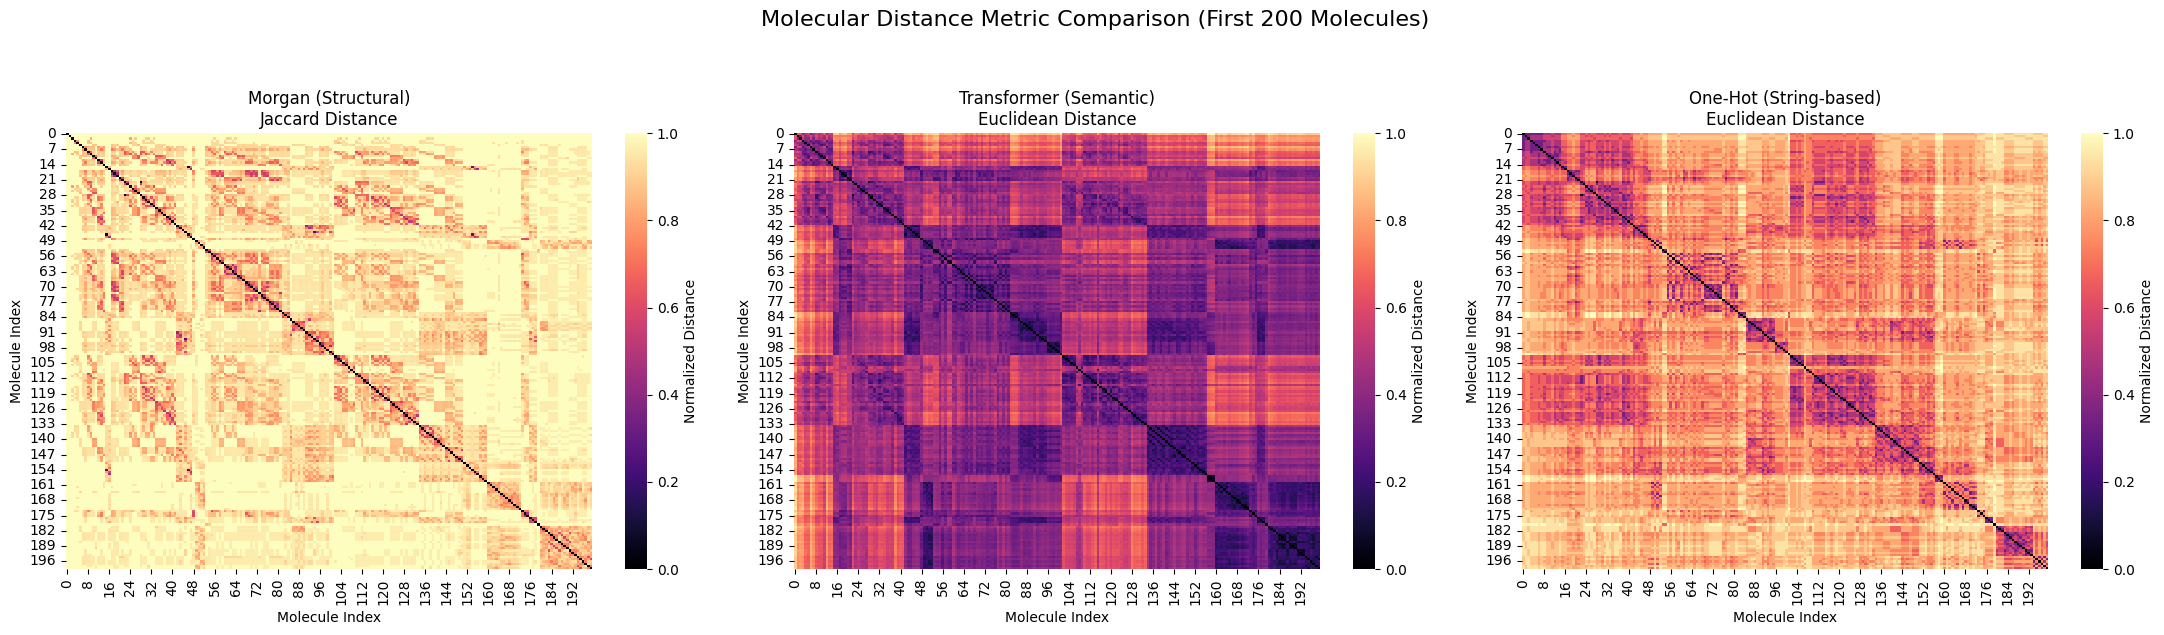

In [21]:
plot_distance_heatmaps(distance_morgan, distance_selfies_transformer, distance_selfies_one_hot, subset_size=200)

# Clustering

## Selfies strings

In [22]:
def find_cluster_outliers(df: pl.DataFrame, labels: np.ndarray, kmeans_model, X_matrix, top_n: int = 3):
    """
    Finds and prints the molecules furthest from their cluster centroids.
    """
    # 1. Get distances to ALL centroids for every molecule
    # Shape: (n_molecules, n_clusters)
    distances_to_all = kmeans_model.transform(X_matrix)
    
    # 2. Extract distance only to the ASSIGNED centroid
    assigned_distances = [distances_to_all[i, labels[i]] for i in range(len(labels))]
    
    # 3. Add to a temporary dataframe for easy analysis
    outlier_df = df.with_columns([
        pl.Series("cluster_id", labels),
        pl.Series("dist_to_centroid", assigned_distances)
    ])

    print(f"\n{'!'*20} CLUSTER OUTLIERS (Top {top_n} per cluster) {'!'*20}")
    
    for cluster in range(kmeans_model.n_clusters):
        # Sort by distance (descending) to find the furthest molecules
        cluster_outliers = (
            outlier_df.filter(pl.col("cluster_id") == cluster)
            .sort("dist_to_centroid", descending=True)
            .head(top_n)
        )
        
        print(f"\n[Cluster {cluster}] Furthest Molecules:")
        for row in cluster_outliers.iter_rows(named=True):
            print(f"  - {row['mol_id']} ({row['structure_class']}): "
                  f"Dist={row['dist_to_centroid']:.2f}, SMILES={row['canonical_smiles']}")

In [28]:
def analyze_molecular_clusters(df: pl.DataFrame, method: str, n_clusters: int = 5):
    """
    Refactored to use ClusterAnalysis framework for logic,
    while keeping the custom subplots and dominant-class annotation.
    """
    # 1. Prepare Matrices (Same as before)
    X_morgan = np.array(df["morgan_fingerprint"].to_list())
    X_transformer = np.array(df["selfies_transformer"].to_list())
    
    onehot_raw = np.array(df["selfies_onehot"].to_list())
    X_onehot = onehot_raw.reshape(onehot_raw.shape[0], -1)

    datasets = {"Morgan": X_morgan, "One-Hot": X_onehot, "Transformer": X_transformer}
    
    # Ground Truth for Evaluation
    true_labels = df["structure_class"].to_list()

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    for i, (name, X) in enumerate(datasets.items()):
        print(f"\n{'='*10} ANALYZING: {name} {'='*10}")
        
        # 2. Initialize Analyzer
        analyzer = ClusterAnalysis(X, true_labels=true_labels, meta_df=df)
        
        # 3. Run Clustering (e.g., KMeans)
        if method == 'kmeans':
            labels = analyzer.run(method='kmeans', n_clusters=n_clusters)
        elif method == 'dbscan':
            labels = analyzer.run(method='dbscan', eps=0.5, min_samples=3)
        elif method == 'hierarchical':
            labels = analyzer.run(method='hierarchical', n_clusters=n_clusters, linkage='ward')
        
        if max(labels) == -1:
            print("skipping ", method)
            continue

        # 4. Evaluate
        analyzer.evaluate()
        
        #if hasattr(analyzer.model_, "transform") or hasattr(analyzer.model_, "predict"):
        #     find_cluster_outliers(df, labels, analyzer.model_, X, top_n=2)
        

        analyzer.analyze_mismatches()
        
        bad_clusters_df = analyzer.get_misclassification_report(n_neighbors=3)
        
        output_dir = f'results/cluster_reports/{name}'
        os.makedirs(output_dir, exist_ok=True)
        save_path = f'{output_dir}/cluster_outlier_report_{method}.csv'
        bad_clusters_df.write_csv(save_path)

        # 6. Custom Visualization Logic
        temp_df = df.with_columns(pl.Series("cluster_id", labels))
        
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        
        ax = axes[i]
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', alpha=0.3, s=25)
        
        summary = (
            temp_df.group_by("cluster_id")
            .agg([
                pl.col("structure_class").mode().first().alias("dom_class"),
                ((pl.col("structure_class") == pl.col("structure_class").mode().first()).sum() / pl.len() * 100).alias("dom_perc")
            ])
            .sort("cluster_id")
        )
        
        # Annotate Plot
        unique_labels = sorted(list(set(labels)))
        for cluster in unique_labels:
            if cluster == -1: continue

            mask = (labels == cluster)
            center_x = np.mean(X_pca[mask, 0])
            center_y = np.mean(X_pca[mask, 1])
            
            row = summary.filter(pl.col("cluster_id") == cluster)
            if not row.is_empty():
                label_text = f"{row['dom_class'][0]}\n{row['dom_perc'][0]:.0f}%"
                
                ax.text(
                    center_x, center_y, 
                    label_text, 
                    fontsize=10, weight='bold', ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2')
                )

        ax.set_title(f"{name} Clusters", fontsize=15, fontweight='bold')

    plt.tight_layout()
    plt.show()


========== ANALYZING: Morgan ==========
--- Running KMEANS ---
Found 5 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.5637
Silhouette Score: 0.0491
Calinski-Harabasz Score: 76.9299

--- Mismatch Analysis ---
Visual Intruders: 189 (Look like they belong elsewhere)
Silhouette Outliers: 144 (Ambiguous assignment)
Label Mismatches: 142 (Don't match cluster's dominant class)
Finding top 3 neighbors for every molecule...
Found 142 mismatches.

========== ANALYZING: One-Hot ==========
--- Running KMEANS ---
Found 5 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.2396
Silhouette Score: 0.0679
Calinski-Harabasz Score: 111.3621

--- Mismatch Analysis ---
Visual Intruders: 369 (Look like they belong elsewhere)
Silhouette Outliers: 226 (Ambiguous assignment)
Label Mismatches: 610 (Don't match cluster's dominant class)
Finding top 3 neighbors for every molecule...
Found 610 mismatches.

========== ANALYZING: Transformer ==========
--- Running KMEANS ---
Found 5

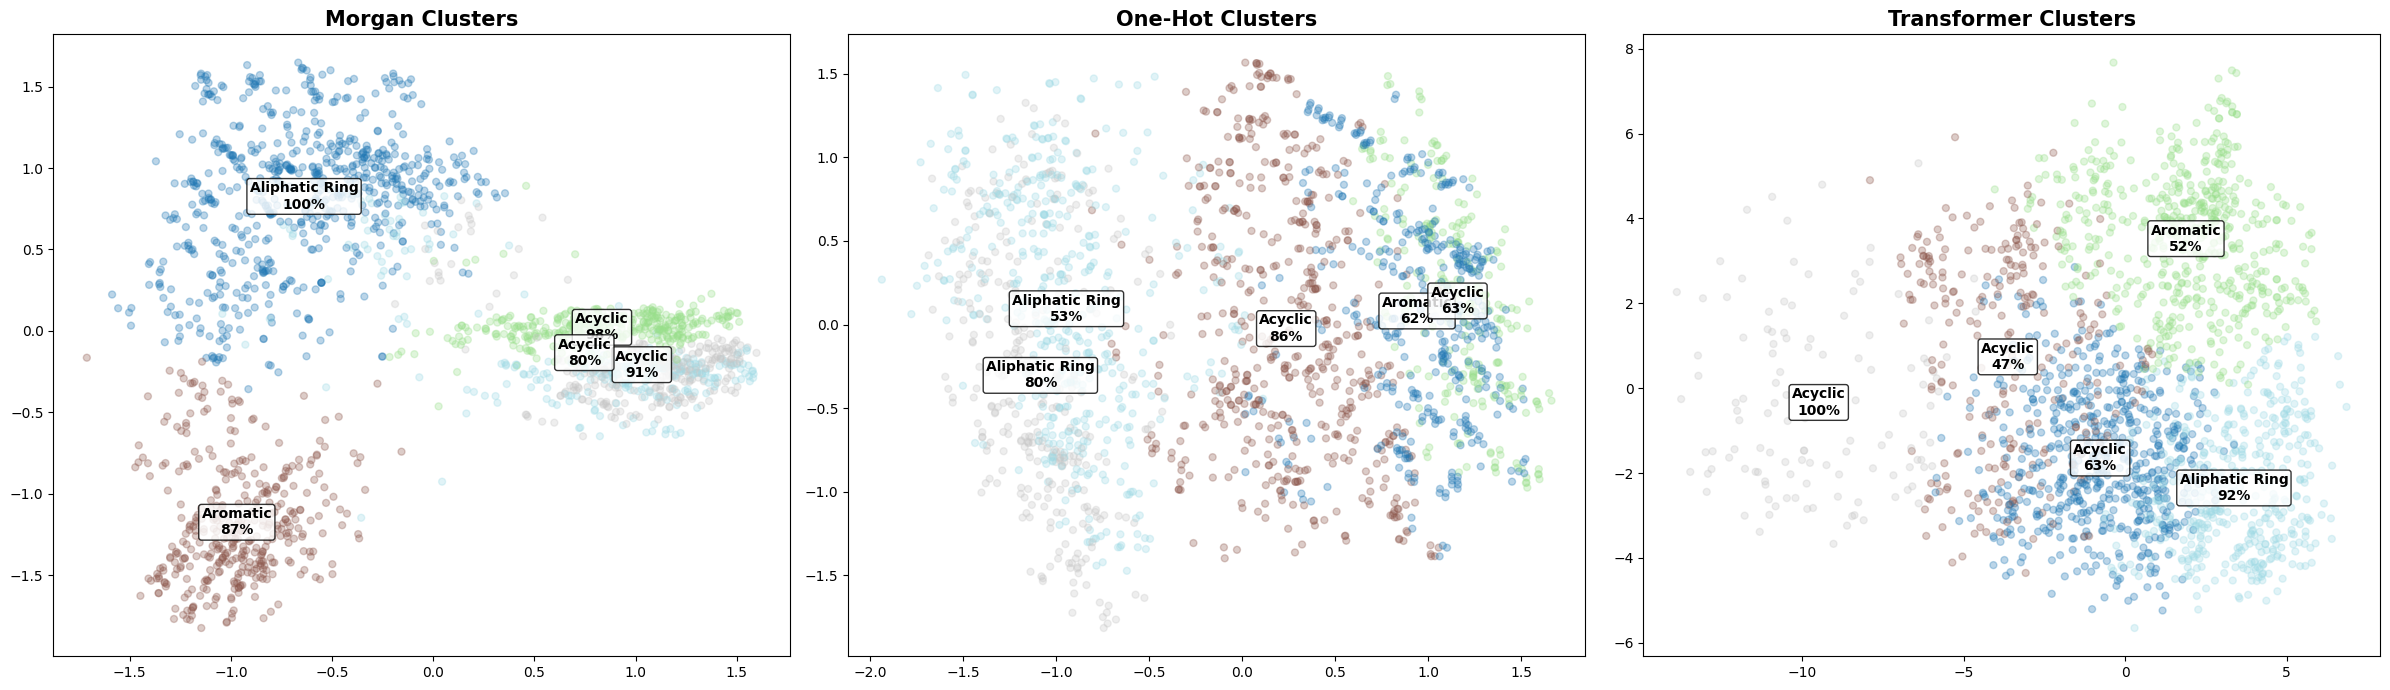

In [31]:
analyze_molecular_clusters(qm9.df, method='kmeans')


========== ANALYZING: Morgan ==========
--- Running DBSCAN ---
skipping  dbscan

========== ANALYZING: One-Hot ==========
--- Running DBSCAN ---
skipping  dbscan

========== ANALYZING: Transformer ==========
--- Running DBSCAN ---
skipping  dbscan


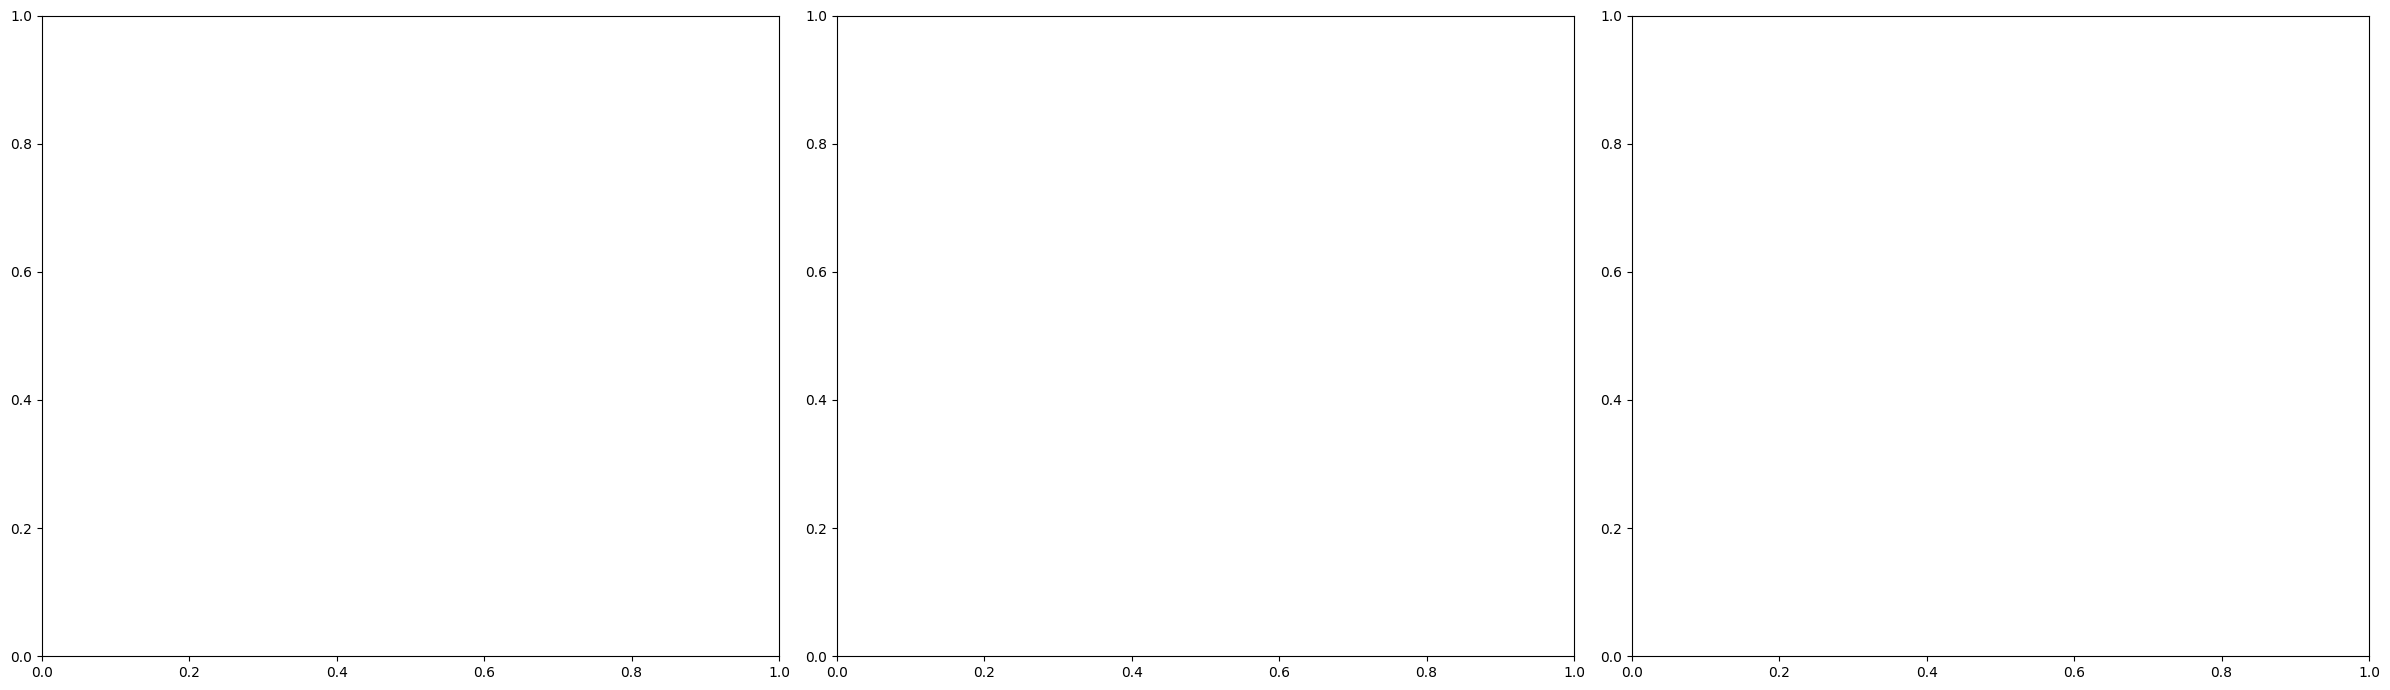

In [30]:
analyze_molecular_clusters(qm9.df, method='dbscan')


========== ANALYZING: Morgan ==========
--- Running HIERARCHICAL ---
Found 5 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.5460
Silhouette Score: 0.0458
Calinski-Harabasz Score: 70.5469

--- Mismatch Analysis ---
Visual Intruders: 182 (Look like they belong elsewhere)
Silhouette Outliers: 210 (Ambiguous assignment)
Label Mismatches: 117 (Don't match cluster's dominant class)
Finding top 3 neighbors for every molecule...
Found 117 mismatches.

========== ANALYZING: One-Hot ==========
--- Running HIERARCHICAL ---
Found 5 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.2695
Silhouette Score: 0.0599
Calinski-Harabasz Score: 101.2170

--- Mismatch Analysis ---
Visual Intruders: 423 (Look like they belong elsewhere)
Silhouette Outliers: 361 (Ambiguous assignment)
Label Mismatches: 604 (Don't match cluster's dominant class)
Finding top 3 neighbors for every molecule...
Found 604 mismatches.

========== ANALYZING: Transformer ==========
--- Running HIERAR

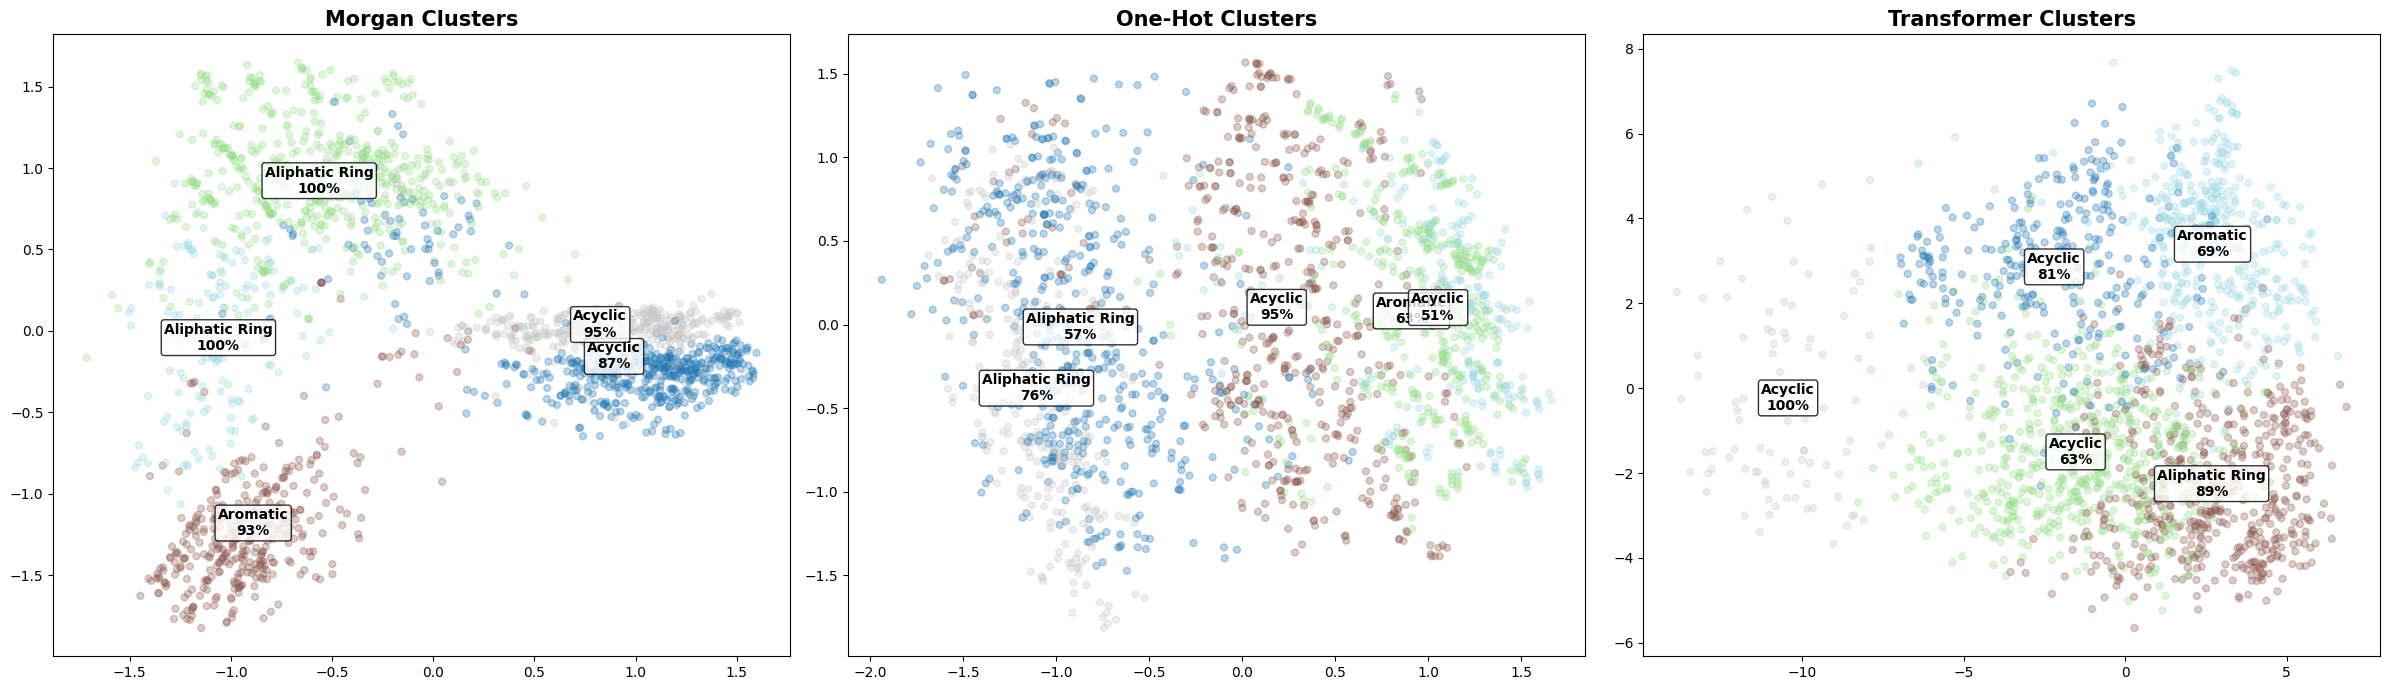

In [32]:
analyze_molecular_clusters(qm9.df, method='hierarchical')


In [27]:
qm9.df

mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_transformer,selfies_onehot
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[f64],list[list[i64]]
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[1.116855, 0.998924, … 0.737373]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]"
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[0.316447, 0.69667, … 1.264199]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]"
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[0.08437, 0.681181, … 0.699162]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]"
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[0.895405, 0.401674, … 0.650952]","[[0, 0, … 0], [1, 0, … 0], … [0, 0, … 1]]"
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[0.981024, 0.386095, … 1.052694]","[[0, 0, … 0], [0, 1, … 0], … [0, 0, … 1]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0, 0, … 0]","[0.299405, -0.013913, … 1.102453]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
"""qm9_2011""","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,"""Aliphatic Ring""",98.101,0.4895,26.3,7,1,0,0,0.4,0,2,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565,"[0, 0, … 0]","[0.233892, 0.030704, … 1.002681]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
"""qm9_2012""","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,"""Aliphatic Ring""",100.141,1.5652,33.03,7,1,0,0,1.0,0,1,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558,"[0, 0, … 0]","[0.537106, -0.137771, … 0.598195]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
